# Decision Tree - Regression
In this notebook, we will be using the decision tree to perform regression on an Advertising dataset. 
We will try to predict the amount of sales for distinct values of TV, radio, and newspaper spend.

The project will follow three phases:
1. Data Preprocessing
2. Model Initialization and Training
3. Model Evaluation

## Data Preprocessing
In this phase, we will process the data, in order to make it usable for our purposes.
This phase contains the following sections
1. Import Modules
2. Read Data
3. Scale Data
4. Split Data

### Import Modules

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Reading Dataset
We read the csv file of the data, and drop the 'Index' column

In [2]:
df = pd.read_csv("Advertising.csv")
df.drop('Index', axis=1, inplace=True)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Scale Data
Here, we scale the data so that every feature is a value between 0 and 1.
We need to do this, so that values with large magnitude don't unduly influence the model.

In [3]:
features_to_scale = ['TV', 'radio', 'newspaper']
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

,TV,radio,newspaper,sales
0,0.969852,0.981522,1.778945,22.1
1,-1.197376,1.082808,0.669579,10.4
2,-1.516155,1.528463,1.783549,9.3
3,0.052050,1.217855,1.286405,18.5
4,0.394182,-0.841614,1.281802,12.9


### Split Data
Now, we split the data into X_train, y_train, X_test, and y_test sets.
- X sets contain the features that will be input to the models.
- y sets contain the actual output outcomes from the model. 
- train sets will be used to train the data.
- test sets will be used to evaluate the data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], random_state=13)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(150, 3)
(50, 3)
(150,)
(50,)


## Model Initialization and Training
Here, we initialize the Decision Tree Regressor using the sci-kit learn library.

The squared_error value in each node indicates the variance of the target variable within that node — smaller squared_error values mean the node is more "pure" (i.e., the predictions are more similar). As we move down the tree, we generally see the squared_error decreasing, indicating better splits that group similar target values together. You can try changing the max_depth parameter to higher values to see how the tree would split the data further beyond these leaf nodes.

For our initial model, we use a max depth of 3. I chose this arbitrarily, as it was easy to plot the resulting tree. Feel Free to change this number.

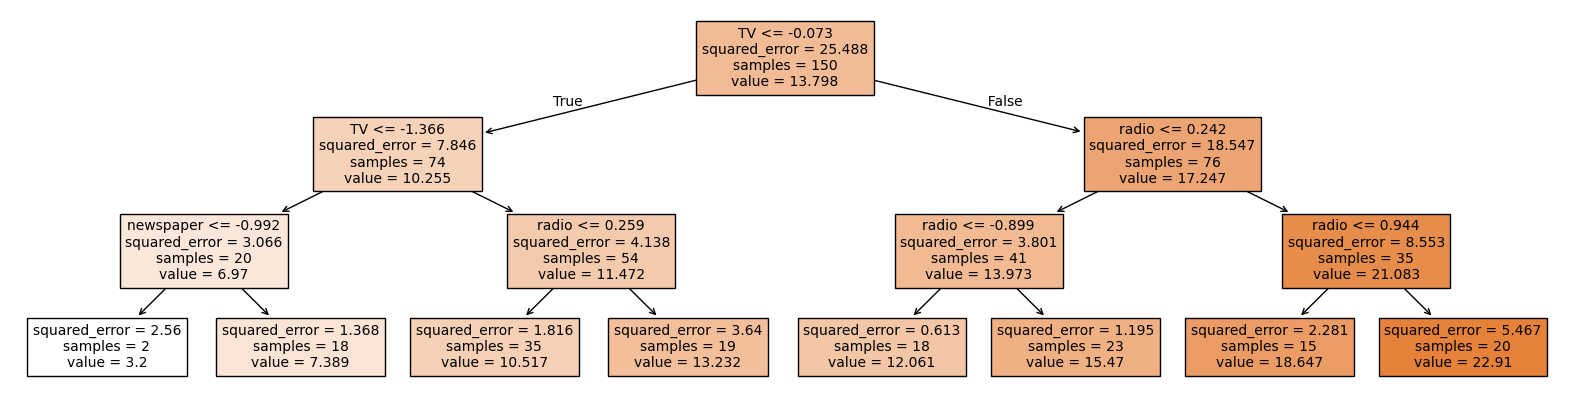

In [5]:
reg = DecisionTreeRegressor(max_depth=3, random_state=13)
reg = reg.fit(X_train, y_train)

plt.figure(figsize=(20,5))
plot_tree(reg,
          feature_names = df.columns, 
          class_names = ['positive', 'negative'], 
          filled = True, 
          fontsize = 10)
plt.show()

## Model Evaluation
- Error Metrics
- Error vs Max Depth Evaluation
- Residuals graph

### Error Metrics
- MSE and RMSE provide a quantitative measure of prediction errors.
- MAE shows average absolute error magnitude.
- R² reflects the proportion of variance explained by the model. A value closer to 1 indicates a better fit.
- These metrics together give a view of how well the linear regression model performs on unseen data

In [6]:
y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error:      {mse}")
print(f"Root Mean Squared error: {rmse}")
print(f"Mean Absolute error:     {mae}")
print(f"R2 score:                {r2}")

Mean squared error:      4.405406858796723
Root Mean Squared error: 2.098906110047975
Mean Absolute error:     1.6076720278958265
R2 score:                0.8591368943095179


### Error vs Max Depth Evaluation
In this section, I wanted to explore how changing max depth impacts the errors, and the difference between the predicted and the actual values.
To do this, I created a graph of actual vs predicted
- Blue line represents the case where there are no errors
- Red represents predicted outputs of the model
- Legend contains various Error metrics

One interesting thing about these graphs is that as we increase the max depth, we see a sort of step output created, where max_depth=1 has red dots in two x-axis position, max_depth=2 has them in four, and so on. The model is able to ouput an exponentially larger amount of values as we increase the max_depth. This is represents an inherent trade-off with the Decision Tree model. As you increase max_depth, there are more possible output values - but also a higher probability to overfit the data.

In this particular case, there is minimal overfitting, so the error rate generally decreases as we increase max_depth

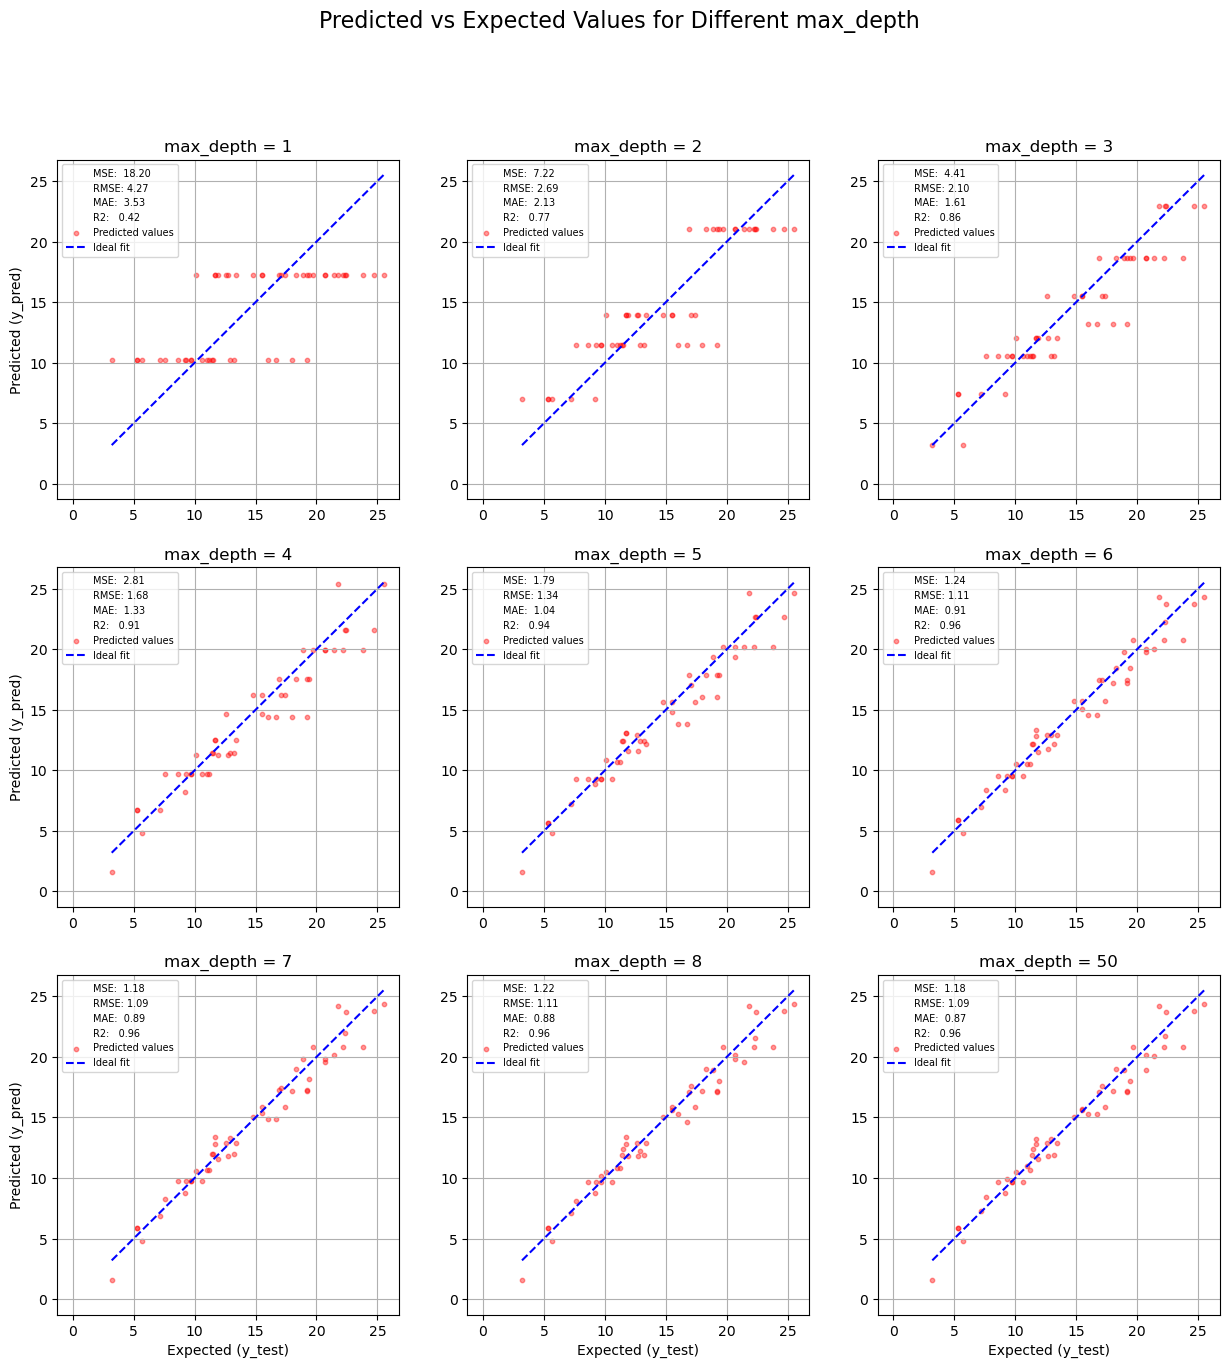

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
depth_values = [1, 2, 3,
                4, 5, 6,
                7, 8, 50]

for i, maxdepth in enumerate(depth_values):
    reg = DecisionTreeRegressor(max_depth=maxdepth, random_state=13)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    ax = axes[i]

    ax.scatter(0,0,alpha=0, color='none', label=f'MSE:  {mse:.2f}')
    ax.scatter(0,0,alpha=0, color='none', label=f'RMSE: {rmse:.2f}')
    ax.scatter(0,0,alpha=0, color='none', label=f'MAE:  {mae:.2f}')
    ax.scatter(0,0,alpha=0, color='none', label=f'R2:   {r2:.2f}')

    ax.scatter(y_test, y_pred, alpha=0.4, s=10, color='red', label='Predicted values')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            color='blue', linestyle='--', label='Ideal fit')
    ax.set_title(f"max_depth = {maxdepth}")
    
    if i % 3 == 0:  # First column of each row
        ax.set_ylabel("Predicted (y_pred)")
    if (i == 6 or i == 7 or i == 8):
        ax.set_xlabel("Actual (y_test)")
        
    ax.grid(True)
    ax.legend(loc='best', fontsize=7)
fig.suptitle("Predicted vs Actual Values for Different max_depth", fontsize=16)
plt.show()

### Residuals Evaluation
A Residual is the difference between the actual and predicted value. In an ideal world, we would have a residual of 0. However in practice, this is often not true. Below, I plot a graph where each blue point is (predicted, residual). The red line running through the center represents the ideal case, where there are no errors.

For the residual (y-axis): 
- Positive values $\rightarrow$ prediction too low
- Negative values $\rightarrow$ prediction was too high
- 0 $\rightarrow$ correct prediction

In general, we want residual plots with the following properties:
- Symmetric distribution clustered towards middle of plot
- Close to 0 y value e.g(0.3 or -1.2, not 60 or 200)
- No clear patterns

For the case where max_depth=3, we can conclude that a linear model is appropriate for modeling this data.
This is because:
- There seems to be a random scatter around zero for most predicted values. This means that on average, the model isn't systemically over- or under-predicting
- The verical lines at certain 'predicted' values (~4, ~8, ~11) come from the fact that we are using decision trees, which discretely partition the feature space, and assign the same value to everything within a single leaf node (with a maxdepth of 3, we can have a maximum of 8 possible ouptut values).

Feel free to change the max depth, and see how the residuals graph changes. Do any patterns emerge as we increase the max depth?

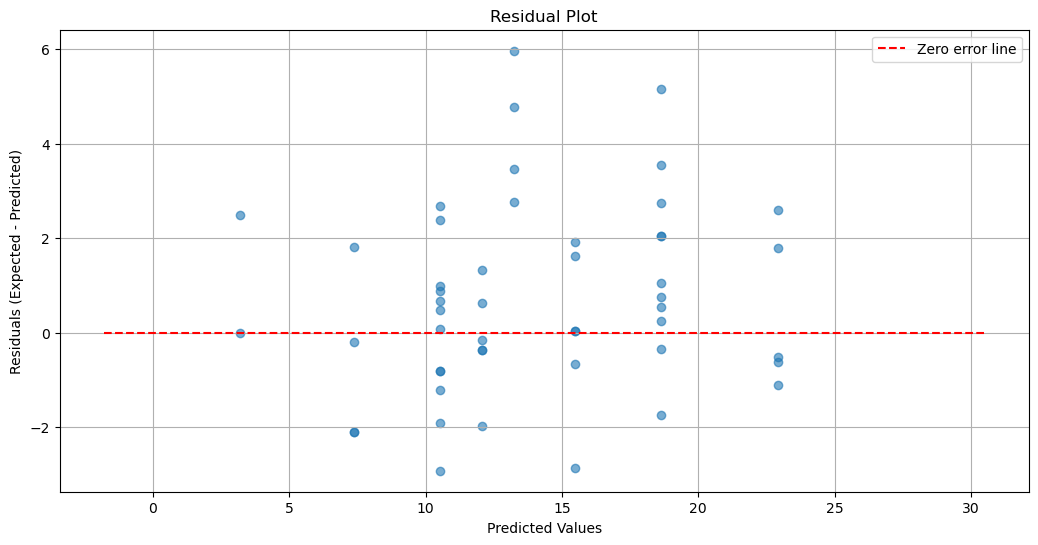

In [8]:
reg = DecisionTreeRegressor(max_depth=3, random_state=13)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize=(12.5, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.hlines(0, min(y_test)-5, max(y_test) + 5, colors='r', linestyles='dashed', label="Zero error line") #Add +- 5 to make graph look cleaner
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.legend()
plt.grid(True)
plt.show()